In [161]:
import numpy as np
import pandas as pd
import netwulf as nw
import networkx as nx
import matplotlib.pyplot as plt

In [162]:
pd.set_option('display.max_rows', 500)

In [163]:
connection_pd = pd.read_csv('./line_station_connectionV1130.csv')
connection_pd

,line_cd,station_cd1,station_cd2,company_cd,line_name,station_name1,station_name2,station_lng1,station_lng2,station_lat1,station_lat2,dc:title,odpt:lineCode,odpt:operator,line,odpt_railway,Con,distance
0,11302,1194,976,2,JR山手線,大崎,五反田,139.728439,139.723822,35.619772,35.625974,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,0.735128
1,11302,976,1661,2,JR山手線,五反田,目黒,139.723822,139.715775,35.625974,35.633923,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.120418
2,11302,1661,1885,2,JR山手線,目黒,恵比寿,139.715775,139.710070,35.633923,35.646685,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.254671
3,11302,1885,725,2,JR山手線,恵比寿,渋谷,139.710070,139.701238,35.646685,35.658871,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.425703
4,11302,725,1663,2,JR山手線,渋谷,原宿,139.701238,139.702592,35.658871,35.670646,山手線,JY,odpt.Operator:JR-East,JR-East.Yamanote,odpt.Railway,1,1.009891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1489,99343,524,889,130,グリーンライン,センター北,北山田,139.578386,139.592258,35.553534,35.561077,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.669461
1490,99343,889,1714,130,グリーンライン,北山田,東山田,139.592258,139.604369,35.561077,35.554302,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.463786
1491,99343,1714,674,130,グリーンライン,東山田,高田,139.604369,139.619944,35.554302,35.549713,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.774937
1492,99343,674,653,130,グリーンライン,高田,日吉本町,139.619944,139.633554,35.549713,35.549883,グリーンライン,G,odpt.Operator:YokohamaMunicipal,YokohamaMunicipal.Green,odpt.Railway,1,1.513431


In [164]:
# list of all the stations in the connection data

station_list_connection_1 = connection_pd[['station_cd1', 'station_name1']].rename(columns={'station_cd1': 'station_id', 'station_name1': 'S12_001'}).drop_duplicates()
station_list_connection_2 = connection_pd[['station_cd2', 'station_name2']].rename(columns={'station_cd2': 'station_id', 'station_name2': 'S12_001'}).drop_duplicates()
station_list_pd = pd.concat([station_list_connection_1, station_list_connection_2]).drop_duplicates().reset_index(drop=True)
station_list_pd

,station_id,S12_001
0,1194,大崎
1,976,五反田
2,1661,目黒
3,1885,恵比寿
4,725,渋谷
...,...,...
1108,424,芝山千代田
1109,1631,松戸
1110,594,羽田空港第2ターミナル
1111,1448,東葉勝田台


In [165]:
# list of all the stations in the passenger survey data that are also in the connection data

passenger_survey_pd = pd.read_csv('./pass_survey_tokyov1109.csv')
passenger_survey_pd['station_id'] = passenger_survey_pd['station_id'].astype(int)
passenger_survey_pd[passenger_survey_pd['station_id'].isin(station_list_pd['station_id'].values)]

matching_passenger_survey_pd = passenger_survey_pd[passenger_survey_pd['station_id'].isin(station_list_pd['station_id'].values)].reset_index(drop=True)
matching_passenger_survey_pd

,S12_001,2013,2014,2015,2016,2017,2018,2019,station_id
0,あざみ野,214782,212344,214866,215440,216601,217261,216163,339
1,いずみ中央,15993,15612,15772,15850,16016,16195,16257,2133
2,いずみ野,14181,13939,14033,13971,13969,13962,13752,1948
3,おゆみ野,4440,4505,4664,4870,5031,5105,5221,215
4,お台場海浜公園,16357,16515,17537,17488,16944,17165,16899,43
...,...,...,...,...,...,...,...,...,...
1101,鹿島田,33574,34966,35210,36740,37340,38322,38322,1462
1102,麹町,58149,59871,61119,63526,65797,66433,65607,486
1103,麻布十番,80122,82251,83556,85071,87728,88741,86285,1713
1104,黄金町,22198,22198,22035,22246,22576,22958,22987,1649


In [167]:
# and now we need to make sure nodes in the passenger survey match up with nodes in the connection data
# the passenger_survey_pd only has nodes that are in the station_list_pd, so we can just filter the station_list_pd to only include those nodes

# note that both data had stations that were not in the other

station_list_pd = station_list_pd[station_list_pd['station_id'].isin(matching_passenger_survey_pd['station_id'].values)].reset_index(drop=True)
station_list_pd

,station_id,S12_001
0,1194,大崎
1,976,五反田
2,1661,目黒
3,1885,恵比寿
4,725,渋谷
...,...,...
1101,424,芝山千代田
1102,1631,松戸
1103,594,羽田空港第2ターミナル
1104,1448,東葉勝田台


In [177]:
#remove any connections between stations that are not in the station_list_pd
station_node_pd = connection_pd[connection_pd['station_cd1'].isin(station_list_pd['station_id'].values) & connection_pd['station_cd2'].isin(station_list_pd['station_id'].values)][['line', 'station_cd1', 'station_cd2', 'distance']].drop_duplicates()
station_node_pd

,line,station_cd1,station_cd2,distance
0,JR-East.Yamanote,1194,976,0.735128
1,JR-East.Yamanote,976,1661,1.120418
2,JR-East.Yamanote,1661,1885,1.254671
3,JR-East.Yamanote,1885,725,1.425703
4,JR-East.Yamanote,725,1663,1.009891
...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461
1490,YokohamaMunicipal.Green,889,1714,1.463786
1491,YokohamaMunicipal.Green,1714,674,1.774937
1492,YokohamaMunicipal.Green,674,653,1.513431


In [178]:
# testing:

first_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 1194) & (station_node_pd['station_cd2'] == 976)]
second_row = station_node_pd.loc[(station_node_pd['station_cd1'] == 976) & (station_node_pd['station_cd2'] == 1194)]
print(first_row)
print(second_row)

               line  station_cd1  station_cd2  distance
0  JR-East.Yamanote         1194          976  0.735128
Empty DataFrame
Columns: [line, station_cd1, station_cd2, distance]
Index: []


In [179]:
# build graph structure using networkx
G = nx.Graph()
G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

(<Figure size 480x480 with 1 Axes>, <Axes: >)

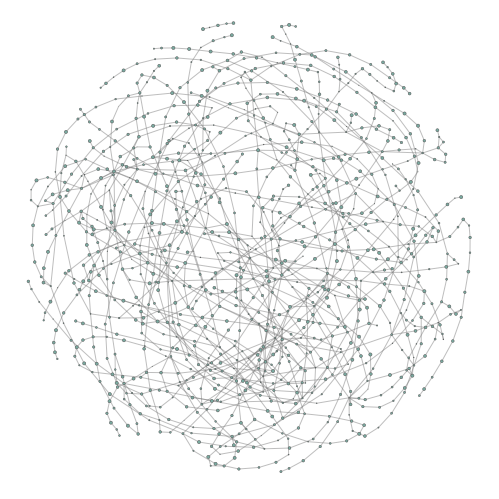

In [180]:
for n, data in G.nodes(data=True):
    data['size'] = np.random.random()

stylized_network, config = nw.visualize(G, plot_in_cell_below=True)

nw.draw_netwulf(stylized_network, config)

In [181]:
#normalize distances
d_max = station_node_pd['distance'].max()
station_node_pd['nor_distance'] = station_node_pd['distance'].apply(lambda x: (x - 0.1) / (d_max - 0.1))
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance
0,JR-East.Yamanote,1194,976,0.735128,0.048421
1,JR-East.Yamanote,976,1661,1.120418,0.077795
2,JR-East.Yamanote,1661,1885,1.254671,0.088030
3,JR-East.Yamanote,1885,725,1.425703,0.101069
4,JR-East.Yamanote,725,1663,1.009891,0.069368
...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757


In [182]:
#get operator name from line name
#TODO this could be redundant, could just directly get operator instead
station_node_pd['operator'] = station_node_pd['line'].apply(lambda x: x.split('.')[0])
station_node_pd

,line,station_cd1,station_cd2,distance,nor_distance,operator
0,JR-East.Yamanote,1194,976,0.735128,0.048421,JR-East
1,JR-East.Yamanote,976,1661,1.120418,0.077795,JR-East
2,JR-East.Yamanote,1661,1885,1.254671,0.088030,JR-East
3,JR-East.Yamanote,1885,725,1.425703,0.101069,JR-East
4,JR-East.Yamanote,725,1663,1.009891,0.069368,JR-East
...,...,...,...,...,...,...
1489,YokohamaMunicipal.Green,524,889,1.669461,0.119653,YokohamaMunicipal
1490,YokohamaMunicipal.Green,889,1714,1.463786,0.103972,YokohamaMunicipal
1491,YokohamaMunicipal.Green,1714,674,1.774937,0.127694,YokohamaMunicipal
1492,YokohamaMunicipal.Green,674,653,1.513431,0.107757,YokohamaMunicipal


In [183]:
#let's color lines by operator

operators_list = station_node_pd['operator'].unique()
operators_list.sort()
print("Operators:", operators_list)

colors = range(len(station_node_pd['operator'].unique()))
N=len(colors)

cmap = plt.get_cmap("Set3_r")
cmap_list=[]
for i in range(N):
    c=cmap(float(i)/N)
    cmap_list.append(c)

line_color=dict(zip(operators_list,cmap_list))

line_color

Operators: ['Hokuso' 'JR-East' 'Keikyu' 'Keio' 'Keisei' 'Minatomirai' 'Odakyu'
 'SaitamaRailway' 'Seibu' 'Shibayama' 'ShinKeisei' 'Sotetsu' 'TWR' 'Tobu'
 'Toei' 'TokyoMetro' 'TokyoMonorail' 'Tokyu' 'ToyoRapid'
 'YokohamaMunicipal' 'Yurikamome']


{'Hokuso': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'JR-East': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0),
 'Keikyu': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keio': (0.8, 0.9215686274509803, 0.7725490196078432, 1.0),
 'Keisei': (0.7372549019607844, 0.5019607843137255, 0.7411764705882353, 1.0),
 'Minatomirai': (0.7372549019607844,
  0.5019607843137255,
  0.7411764705882353,
  1.0),
 'Odakyu': (0.8509803921568627, 0.8509803921568627, 0.8509803921568627, 1.0),
 'SaitamaRailway': (0.9882352941176471,
  0.803921568627451,
  0.8980392156862745,
  1.0),
 'Seibu': (0.9882352941176471, 0.803921568627451, 0.8980392156862745, 1.0),
 'Shibayama': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'ShinKeisei': (0.7019607843137254,
  0.8705882352941177,
  0.4117647058823529,
  1.0),
 'Sotetsu': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'TWR': (0.9921568627450981, 0.7058823529411765, 0.3843137254901961, 1.0),
 'Tobu

In [184]:
for link in stylized_network['links']:
    
    line = station_node_pd[((station_node_pd['station_cd1'] == link['source']) & (station_node_pd['station_cd2'] == link['target'])) |
                           ((station_node_pd['station_cd1'] == link['target']) & (station_node_pd['station_cd2'] == link['source']))]
    # print(line)
    if len(line) > 0:
        print(line)#operator
        #link['color'] = line_color[line.iloc[0, 4]]
        link['color'] = line_color[line.iloc[0, 5]] # 0 takes the first row and 5 takes the operator column. this is fine since if multiple lines go between two stations just pick one of them for the color
        dis = line.iloc[0, 3]
        if dis < 1.0:
            link['width'] = 5
        elif dis < 2.0:
            link['width'] = 4
        elif dis < 5.0:
            link['width'] = 3
        elif dis < 10.0:
            link['width'] = 2
        else:
            link['width'] = 1
    else:
        print(link)
        # if didn't print link, then all the lines have been found

               line  station_cd1  station_cd2  distance  nor_distance operator
0  JR-East.Yamanote         1194          976  0.735128      0.048421  JR-East
                line  station_cd1  station_cd2  distance  nor_distance  \
28  JR-East.Yamanote         1750         1194  1.400128      0.099119   

   operator  
28  JR-East  
                        line  station_cd1  station_cd2  distance  \
296           JR-East.Saikyo         1194         1885  3.063343   
464   JR-East.ShonanShinjuku         1885         1194  3.063343   
1207        Sotetsu.JRDirect         1885         1194  3.063343   

      nor_distance operator  
296       0.225919  JR-East  
464       0.225919  JR-East  
1207      0.225919  Sotetsu  
                        line  station_cd1  station_cd2  distance  \
465   JR-East.ShonanShinjuku         1194          785  1.711485   
1208        Sotetsu.JRDirect         1194          785  1.711485   

      nor_distance operator  
465       0.122856  JR-East  
1208   

In [185]:
#track stations with no

for node in stylized_network['nodes']:
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == node['id']] #node id is station name in english
    if sta.shape[0] == 0:
        print(node['id'], sta.shape[0])
    if len(sta) > 0:
        #node['color'] = line_color[station_node_pd[station_node_pd['station_en'] == node['id']].iloc[0, 4]]
        if not station_node_pd[station_node_pd['station_cd1'] == node['id']].empty:
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd1'] == node['id']].iloc[0, 5]]
            sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
            if sta_mean < 10000:
                node['radius'] = 1.5
            elif sta_mean < 100000:
                node['radius'] = 2.5
            elif sta_mean < 500000:
                node['radius'] = 4
            elif sta_mean < 1000000:
                node['radius'] = 7
            elif sta_mean < 2000000:
                node['radius'] = 9
            else:
                node['radius'] = 10
        elif not station_node_pd[station_node_pd['station_cd2'] == node['id']].empty: #some stations only appear in station_cd2 column 
            node['color'] = line_color[station_node_pd[station_node_pd['station_cd2'] == node['id']].iloc[0, 5]] 
            sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
            if sta_mean < 10000:
                node['radius'] = 1.5
            elif sta_mean < 100000:
                node['radius'] = 2.5
            elif sta_mean < 500000:
                node['radius'] = 4
            elif sta_mean < 1000000:
                node['radius'] = 7
            elif sta_mean < 2000000:
                node['radius'] = 9
            else:
                node['radius'] = 10
    else:
        print("station not found in survey data:", node['id'])
    # highlight major stations in green
    if node['id'] in ['Shibuya', 'Shinjuku', 'Ikebukuro', 'Yokohama', 'Takadanobaba', 'Tokyo', 'Shimbashi', 'Shinagawa']:
        node['color'] = "lawngreen"

for node in stylized_network['nodes']:
    print(node) 
# nw.draw_netwulf(stylized_network, config)

{'id': 1194, 'x': 515.4656994185768, 'y': 664.9810186700927, 'x_canvas': 443.2328497092884, 'y_canvas': 517.9905093350463, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 976, 'x': 420.68116051907054, 'y': 623.3222487127996, 'x_canvas': 395.8405802595353, 'y_canvas': 497.1611243563998, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 1661, 'x': 398.6211029007094, 'y': 601.7937637803419, 'x_canvas': 384.8105514503547, 'y_canvas': 486.39688189017096, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 1885, 'x': 277.4175556941844, 'y': 548.3080145649226, 'x_canvas': 324.20877784709216, 'y_canvas': 459.6540072824613, 'radius': 4, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id': 725, 'x': 54.50302183625283, 'y': 413.33777222449936, 'x_canvas': 212.75151091812643, 'y_canvas': 392.16888611224965, 'radius': 10, 'color': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0)}
{'id'

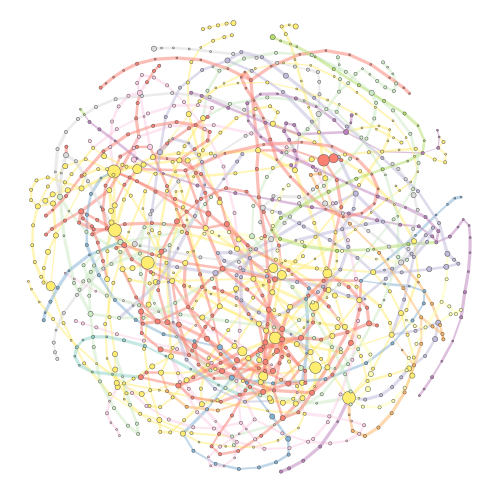

In [186]:
fig, ax = nw.draw_netwulf(stylized_network, config)
plt.show()

In [187]:
print("number of edges:", len(stylized_network['links']))
print("number of nodes:", len(stylized_network['nodes']))
print("passenger count means for stations with more than 500k passengers in 2019:")
for sta in passenger_survey_pd[passenger_survey_pd['2019'] > 2000000].groupby(by='station_id'):
    print(str(sta[0]) + ': {}'.format(sta[1]['2019'].mean()))

number of edges: 1285
number of nodes: 1106
passenger count means for stations with more than 500k passengers in 2019:
277: 2662632.0
725: 2704384.0
1102: 2101709.0
1872: 3265570.0


725 {'group': (1.0, 0.9294117647058824, 0.43529411764705883, 1.0), 'size': 10}


(<Figure size 480x480 with 1 Axes>, <Axes: >)

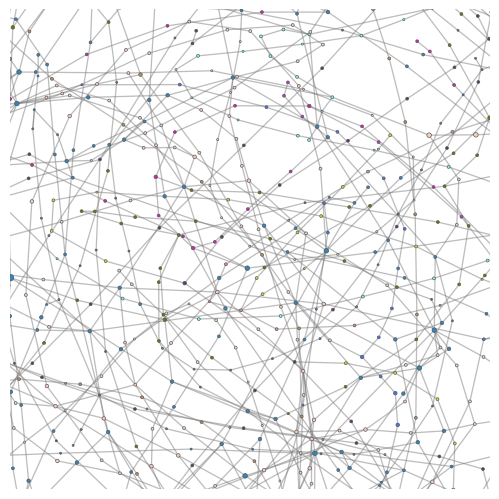

In [188]:
# now let's create a test graph:

test_G = nx.Graph()
test_G = nx.from_pandas_edgelist(station_node_pd, 'station_cd1', 'station_cd2', edge_attr=True)

for k, v in test_G.nodes(data=True):
    v['group'] = line_color[station_node_pd[(station_node_pd['station_cd1'] == k) | (station_node_pd['station_cd2'] == k)].iloc[0, 5]]

for n, data in test_G.nodes(data=True):
    sta = passenger_survey_pd[passenger_survey_pd['station_id'] == n]
    if len(sta) > 0:
        sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
        if sta_mean < 10000:
            data['size'] = 1
        elif sta_mean < 100000:
            data['size'] = 2
        elif sta_mean < 500000:
            data['size'] = 3
        else:
            data['size'] = 5
    # elif not station_node_pd[station_node_pd['station_cd2'] == n].empty:
    #     sta = passenger_survey_pd[passenger_survey_pd['station_cd2'] == n]
    #     if len(sta) > 0:
    #         sta_mean = sta[['2013', '2014', '2015', '2016', '2017', '2018', '2019']].values.mean()
    #         if sta_mean < 10000:
    #             data['size'] = 1
    #         elif sta_mean < 100000:
    #             data['size'] = 2
    #         elif sta_mean < 500000:
    #             data['size'] = 3
    #         else:
    #             data['size'] = 5
    else:
        data['size'] = 1
    if n == 725: #Shibuya id is 725
        data['size'] = 10
        print(n, data)
test_return, test_config = nw.visualize(test_G, plot_in_cell_below=True)
nw.draw_netwulf(test_return, test_config)


# print(test_G.edges(data=True))

In [189]:
# let's look at the original graph:

import torch
A = nx.adjacency_matrix(G)
torch_A = torch.tensor(A.todense(), dtype=torch.float)
torch_A

tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [1., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.]])

 Getting started with the GNN implementations:

In [190]:
import torch
from torch import nn
from torch_geometric.nn import GCNConv


class GCN(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCN, self).__init__()
        torch.manual_seed(0)
        self.layer_1 = GCNConv(in_features, in_features)
        self.layer_2 = GCNConv(in_features, out_features)
    
    def forward(self, x, edge_index):
        x = self.layer_1(x, edge_index)
        x = torch.relu(x)
        x = self.layer_2(x, edge_index)
        return x

In [191]:
model = GCN(in_features=16, out_features=2)
print(model)

GCN(
  (layer_1): GCNConv(16, 16)
  (layer_2): GCNConv(16, 2)
)


In [213]:
# Get node ordering from graph G — this is the order the adjacency matrix uses
node_order = list(G.nodes())
print(f"Number of nodes in G: {len(node_order)}")

# Aggregate passenger survey by station_id (handles duplicate rows per station)
survey_filtered = passenger_survey_pd[passenger_survey_pd['station_id'].isin(node_order)]
survey_agg = survey_filtered.groupby('station_id')[['2013','2014','2015','2016','2017','2018','2019']].mean()
print(f"Unique stations in survey after aggregation: {len(survey_agg)}")

# Reorder features to match graph node ordering
train_x = torch.tensor(survey_agg.loc[node_order][['2013', '2014', '2015', '2016', '2017']].to_numpy(), dtype=torch.float)
train_y = torch.tensor(survey_agg.loc[node_order][['2018']].to_numpy(), dtype=torch.float)

print(f"train_x shape: {train_x.shape}, train_y shape: {train_y.shape}")
train_x, train_y

Number of nodes in G: 1106
Unique stations in survey after aggregation: 1106
train_x shape: torch.Size([1106, 5]), train_y shape: torch.Size([1106, 1])


(tensor([[276622., 286794., 291344., 309088., 321640.],
         [433593., 437495., 440994., 445040., 455659.],
         [454140., 464606., 472390., 475708., 497118.],
         ...,
         [  9197.,   9371.,   9769.,  10299.,  10543.],
         [ 24492.,  22849.,  25340.,  26060.,  26275.],
         [ 13923.,  14394.,  14876.,  15411.,  16102.]]),
 tensor([[346272.],
         [469334.],
         [516781.],
         ...,
         [ 10874.],
         [ 27371.],
         [ 16562.]]))

In [214]:
# Use same node_order and survey_agg from above
test_x = torch.tensor(survey_agg.loc[node_order][['2014', '2015', '2016', '2017', '2018']].to_numpy(), dtype=torch.float)
test_y = torch.tensor(survey_agg.loc[node_order][['2019']].to_numpy(), dtype=torch.float)

print(f"test_x shape: {test_x.shape}, test_y shape: {test_y.shape}")
# Verify train and test inputs are different
print(f"train_x and test_x are identical: {torch.equal(train_x, test_x)}")

test_x shape: torch.Size([1106, 5]), test_y shape: torch.Size([1106, 1])
train_x and test_x are identical: False


In [216]:
model = GCN(in_features=5, out_features=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Convert graph to proper edge_index format: [2, num_edges] LongTensor
adj = nx.adjacency_matrix(G)
rows, cols = adj.nonzero()
edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
print(f"edge_index shape: {edge_index.shape} (expected [2, num_edges])")

def train(x, y):
    model.train()
    optimizer.zero_grad()
    out = model(x, edge_index)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    return loss

edge_index shape: torch.Size([2, 2570]) (expected [2, num_edges])


In [ ]:

for epoch in range(200):
    loss = train(train_x, train_y)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.2f}")

Epoch 20, Loss: 52059639808.00
Epoch 40, Loss: 51846086656.00
Epoch 60, Loss: 33611528192.00
Epoch 80, Loss: 24855324672.00
Epoch 100, Loss: 24132124672.00
Epoch 120, Loss: 24096161792.00
Epoch 140, Loss: 24062672896.00
Epoch 160, Loss: 24027348992.00
Epoch 180, Loss: 24005492736.00
Epoch 200, Loss: 23990855680.00


In [218]:
model.eval()
with torch.no_grad():
    train_out = model(train_x, edge_index)
    train_loss = criterion(train_out, train_y)
    print(f"Train MSE: {train_loss.item():.2f}")

    test_out = model(test_x, edge_index)
    test_loss = criterion(test_out, test_y)
    print(f"Test MSE: {test_loss.item():.2f}")

    # Show sample predictions to verify they differ
    print(f"\nSample predictions (first 5 nodes):")
    print(f"Train pred: {train_out[:5].squeeze().tolist()}")
    print(f"Train true: {train_y[:5].squeeze().tolist()}")
    print(f"Test pred:  {test_out[:5].squeeze().tolist()}")
    print(f"Test true:  {test_y[:5].squeeze().tolist()}")

Train MSE: 23990194176.00
Test MSE: 19411175424.00

Sample predictions (first 5 nodes):
Train pred: [510501.375, 334230.28125, 375165.15625, 538388.5, 1089667.75]
Train true: [346272.0, 469334.0, 516781.0, 415337.0, 2497806.0]
Test pred:  [524142.46875, 342039.6875, 383024.03125, 548897.4375, 1103628.375]
Test true:  [346272.0, 468629.0, 517265.0, 413194.0, 2704384.0]
